# Key Research Questions and Analyses

This file answers these four following questions. 
1. **Genre Evolution:** Which niche genres have transitioned to the mainstream over the past decade? What do their lifecycle trajectories look like?
2. **Publisher Specialization:** Is there a statistically significant correlation between a publisher’s genre focus and their financial performance?
3. **Indie Breakthroughs:** Through what types of genre innovation (e.g., Roguelikes, Cozy Games) do indie titles achieve market breakthroughs?
4. **Market Distribution:** What is the statistical genre distribution among the Global Top 100 best-selling games across longitudinal trend lines?

In [31]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)

def parse_owner_mid(value):
    text = str(value).replace(",", "")
    if pd.isna(value) or ".." not in text:
        return np.nan
    try:
        low, high = (float(p) for p in text.split("..", 1))
    except ValueError:
        return np.nan
    return (low + high) / 2

games = pd.read_csv("Cleaned_Data/games_clean.csv")
games["release_year"] = pd.to_datetime(games["release_date"], errors="coerce").dt.year
games["owner_mid"] = games["owners_range"].apply(parse_owner_mid)
genres = pd.read_csv("Cleaned_Data/genres_clean.csv").dropna(subset=["app_id", "genre"]).drop_duplicates()
tags = pd.read_csv("Cleaned_Data/tags_clean.csv").dropna(subset=["app_id", "tag"]).drop_duplicates()
reviews = pd.read_csv("Cleaned_Data/reviews_clean.csv")
matched = pd.read_csv("Cleaned_Data/games_vgsales_matched.csv")
vgsales = pd.read_csv("Data/vgsales.csv")

## 1. Genre Evolution

Goal: identify genres or microgenre tags whose release-share trajectory moved from niche to mainstream during the most recent decade available in the Steam data.

The genre table has broad labels, so this section also analyzes tags as microgenres. This is especially useful for concepts like `Roguelike`, `Cozy`, `Survival Craft`, and `Metroidvania`.


In [32]:
max_year = int(games["release_year"].dropna().max())
decade = list(range(max_year - 9, max_year + 1))
decade_games = games[games["release_year"].isin(decade)][["app_id", "release_year"]].copy()
decade_games["release_year"] = decade_games["release_year"].astype(int)
releases_per_year = decade_games.groupby("release_year").size().rename("year_releases")

tag_yearly = (
    tags.merge(decade_games, on="app_id")
    .groupby(["tag", "release_year"]).size().rename("count").reset_index()
    .merge(releases_per_year, on="release_year")
)
tag_yearly["share"] = tag_yearly["count"] / tag_yearly["year_releases"]

mid = decade[len(decade) // 2]
half_share = (
    tag_yearly.assign(period=np.where(tag_yearly["release_year"] >= mid, "late_share", "early_share"))
    .groupby(["tag", "period"])["share"].mean()
    .unstack(fill_value=0.0)
)
half_share["growth"] = half_share["late_share"] - half_share["early_share"]
tag_lifecycle = (
    half_share[(half_share["early_share"] <= 0.10) & (half_share["late_share"] >= 0.05)]
    .sort_values("growth", ascending=False)
    .reset_index()
    .rename(columns={"tag": "term"})
)
print(f"Tag lifecycle window: {decade[0]}-{decade[-1]}")
tag_lifecycle.head(10)

Tag lifecycle window: 2015-2024


period,term,early_share,late_share,growth
0,3D,0.033079,0.230640,0.197561
1,Colorful,0.055501,0.178419,0.122918
2,Action-Adventure,0.025451,0.113994,0.088543
3,Exploration,0.057066,0.145114,0.088048
4,Cute,0.069057,0.156318,0.087261
5,Combat,0.010812,0.096480,0.085668
6,2D Platformer,0.015935,0.085168,0.069233
7,Linear,0.013212,0.081301,0.068089
8,Fantasy,0.066820,0.133723,0.066904
9,Relaxing,0.045703,0.111971,0.066269


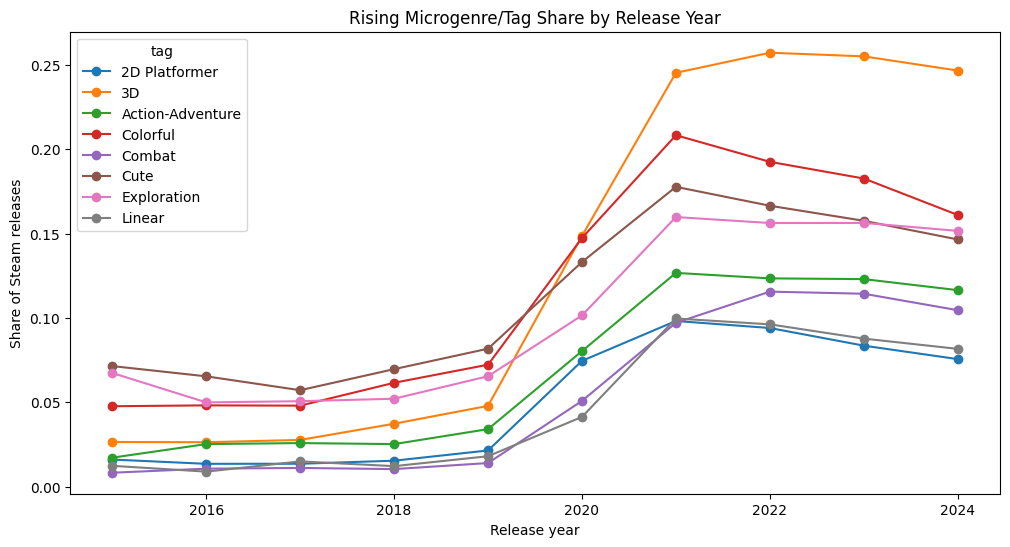

In [33]:
selected_terms = tag_lifecycle.head(8)["term"].tolist()
pivot = (
    tag_yearly[tag_yearly["tag"].isin(selected_terms)]
    .pivot_table(index="release_year", columns="tag", values="share", fill_value=0)
)
ax = pivot.plot(figsize=(12, 6), marker="o")
ax.set_title("Rising Microgenre/Tag Share by Release Year")
ax.set_ylabel("Share of Steam releases")
ax.set_xlabel("Release year")
plt.show()

## 3. Indie Breakthroughs

In [34]:
cols = ["app_id", "name", "developer", "publisher", "owner_mid", "release_year", "price", "is_free"]
g = games[cols]
dev_eq_pub = g["developer"].fillna("").str.lower() == g["publisher"].fillna("").str.lower()
indie_ids = (
    set(genres.loc[genres["genre"].str.lower().eq("indie"), "app_id"])
    | set(tags.loc[tags["tag"].str.lower().eq("indie"), "app_id"])
    | set(g.loc[dev_eq_pub, "app_id"])
)

indie_games = g[g["app_id"].isin(indie_ids)].dropna(subset=["owner_mid"])
indie_games = indie_games[indie_games["owner_mid"] > 0].copy()
breakout_threshold = indie_games["owner_mid"].quantile(0.90)
indie_games["is_breakout"] = indie_games["owner_mid"] >= breakout_threshold
baseline_rate = indie_games["is_breakout"].mean()

innovation_groups = {
    "Roguelike/Roguelite": ["Roguelike", "Roguelite", "Rogue-like", "Traditional Roguelike"],
    "Cozy/Life Sim": ["Cozy", "Wholesome", "Relaxing", "Life Sim", "Farming Sim", "Cute"],
    "Survival Craft": ["Survival", "Crafting", "Open World Survival Craft", "Base Building"],
    "Deckbuilder/Card": ["Deckbuilding", "Card Game", "Card Battler", "Collectible Card Game"],
    "Metroidvania/Soulslike": ["Metroidvania", "Souls-like", "Difficult", "Precision Platformer"],
    "Automation/Colony Sim": ["Automation", "Colony Sim", "Resource Management", "Factory"],
}

indie_tag_set = tags[tags["app_id"].isin(indie_games["app_id"])][["app_id", "tag"]].drop_duplicates()
rows = []
for group, terms in innovation_groups.items():
    ids = set(indie_tag_set.loc[indie_tag_set["tag"].isin(terms), "app_id"])
    sub = indie_games[indie_games["app_id"].isin(ids)]
    if sub.empty:
        rows.append({"innovation_type": group, "games": 0, "breakouts": 0,
                     "breakout_rate": np.nan, "lift_vs_indie_baseline": np.nan})
        continue
    rate = sub["is_breakout"].mean()
    rows.append({
        "innovation_type": group,
        "games": len(sub),
        "breakouts": int(sub["is_breakout"].sum()),
        "breakout_rate": rate,
        "lift_vs_indie_baseline": rate / baseline_rate if baseline_rate else np.nan,
    })
innovation_summary = pd.DataFrame(rows).sort_values("lift_vs_indie_baseline", ascending=False)
print("Indie breakout threshold owner_mid:", breakout_threshold)
innovation_summary

Indie breakout threshold owner_mid: 35000.0


,innovation_type,games,breakouts,breakout_rate,lift_vs_indie_baseline
4,Metroidvania/Soulslike,12104,2617,0.216210,1.429350
2,Survival Craft,14113,2839,0.201162,1.329872
5,Automation/Colony Sim,5868,1038,0.176892,1.169422
0,Roguelike/Roguelite,9677,1639,0.169371,1.119701
1,Cozy/Life Sim,27603,3862,0.139912,0.924953
3,Deckbuilder/Card,4061,517,0.127309,0.841630


## 4. Market Distribution: Global Top 100 Genre Trends

This section uses the original `Data/vgsales.csv`, because it has a broad historical console/PC market view with `Genre`, `Year`, and `Global_Sales`.

In [35]:
vgs = vgsales.copy()
vgs["Year"] = pd.to_numeric(vgs["Year"], errors="coerce")
vgs["Global_Sales"] = pd.to_numeric(vgs["Global_Sales"], errors="coerce")
vgs = vgs.dropna(subset=["Year", "Genre", "Global_Sales"])
vgs["Year"] = vgs["Year"].astype(int)

overall_top100 = vgs.nlargest(100, "Global_Sales")
overall_top100_distribution = (
    overall_top100.groupby("Genre")
    .agg(games=("Name", "count"), global_sales_m=("Global_Sales", "sum"))
    .sort_values("games", ascending=False)
)
totals = overall_top100_distribution[["games", "global_sales_m"]].sum()
overall_top100_distribution["game_share"] = overall_top100_distribution["games"] / totals["games"]
overall_top100_distribution["sales_share"] = overall_top100_distribution["global_sales_m"] / totals["global_sales_m"]
print("Overall Global Top 100 genre distribution")
overall_top100_distribution

Overall Global Top 100 genre distribution


,games,global_sales_m,game_share,sales_share
Genre,,,,
Shooter,22,257.56,0.22,0.176172
Platform,16,251.92,0.16,0.172314
Role-Playing,15,205.45,0.15,0.140529
Action,12,156.87,0.12,0.107300
Racing,10,147.93,0.10,0.101185
Misc,9,125.97,0.09,0.086164
Sports,6,177.01,0.06,0.121076
Simulation,4,54.23,0.04,0.037094
Puzzle,3,53.37,0.03,0.036505


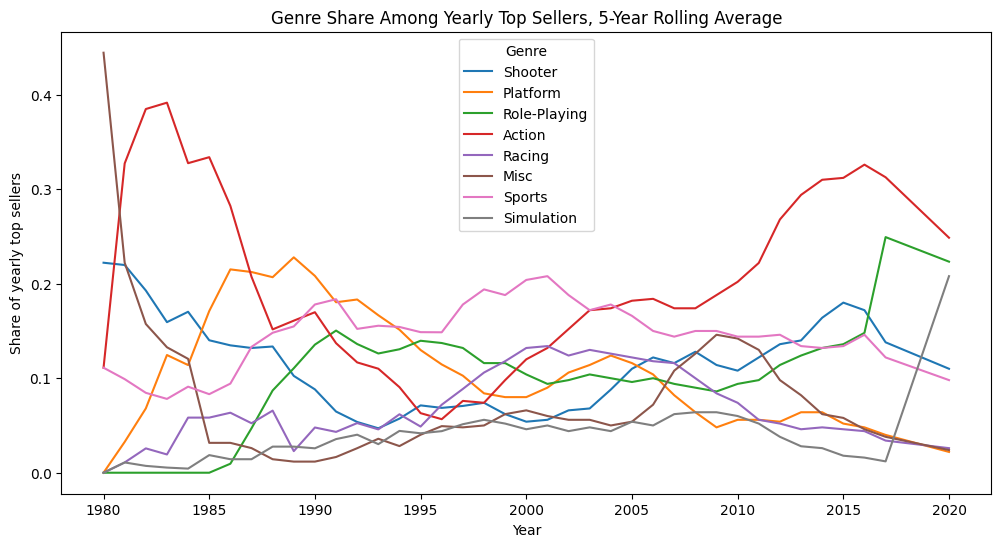

In [36]:
yearly_top = (
    vgs.sort_values(["Year", "Global_Sales"], ascending=[True, False])
    .groupby("Year", group_keys=False)
    .head(100)
)
yearly_counts = yearly_top.groupby(["Year", "Genre"])["Name"].count().rename("games").reset_index()
yearly_totals = yearly_top.groupby("Year")["Name"].count().rename("year_top_games")
yearly_counts = yearly_counts.merge(yearly_totals, on="Year")
yearly_counts["genre_share"] = yearly_counts["games"] / yearly_counts["year_top_games"]
trend_pivot = yearly_counts.pivot_table(index="Year", columns="Genre", values="genre_share", fill_value=0)
rolling_trend = trend_pivot.rolling(5, min_periods=1).mean()
top_overall_genres = overall_top100_distribution.head(8).index.tolist()
ax = rolling_trend[top_overall_genres].plot(figsize=(12, 6))
ax.set_title("Genre Share Among Yearly Top Sellers, 5-Year Rolling Average")
ax.set_ylabel("Share of yearly top sellers")
ax.set_xlabel("Year")
plt.show()

## 5. Market Distribution: Genre Trends (Steam-Matched Dataset)

Same analysis as Section 4, but using `Cleaned_Data/games_vgsales_matched.csv` —
the 1,854 Steam games that were successfully matched to VGChartz entries.

In [37]:
primary_genre = (
    genres.sort_values("genre")
    .groupby("app_id")["genre"].first()
    .reset_index()
)
mdf = (
    matched.copy()
    .assign(release_year=lambda d: pd.to_datetime(d["release_date"], errors="coerce").dt.year,
            owner_mid=lambda d: d["owners_range"].apply(parse_owner_mid))
    .merge(primary_genre, on="app_id", how="left")
    .dropna(subset=["vg_global_sales", "genre"])
)

m_top100 = mdf.nlargest(100, "vg_global_sales")
m_top100_dist = (
    m_top100.groupby("genre")
    .agg(games=("name", "count"), global_sales_m=("vg_global_sales", "sum"))
    .sort_values("games", ascending=False)
)
totals_m = m_top100_dist[["games", "global_sales_m"]].sum()
m_top100_dist["game_share"] = m_top100_dist["games"] / totals_m["games"]
m_top100_dist["sales_share"] = m_top100_dist["global_sales_m"] / totals_m["global_sales_m"]
print("Matched dataset — Overall Top 100 genre distribution")
m_top100_dist


Matched dataset — Overall Top 100 genre distribution


,games,global_sales_m,game_share,sales_share
genre,,,,
Action,74,416.64,0.74,0.690556
Adventure,8,37.44,0.08,0.062055
RPG,7,45.25,0.07,0.074999
Casual,4,66.77,0.04,0.110667
Simulation,2,13.23,0.02,0.021928
Indie,2,10.47,0.02,0.017353
Sports,2,8.53,0.02,0.014138
Free To Play,1,5.01,0.01,0.008304


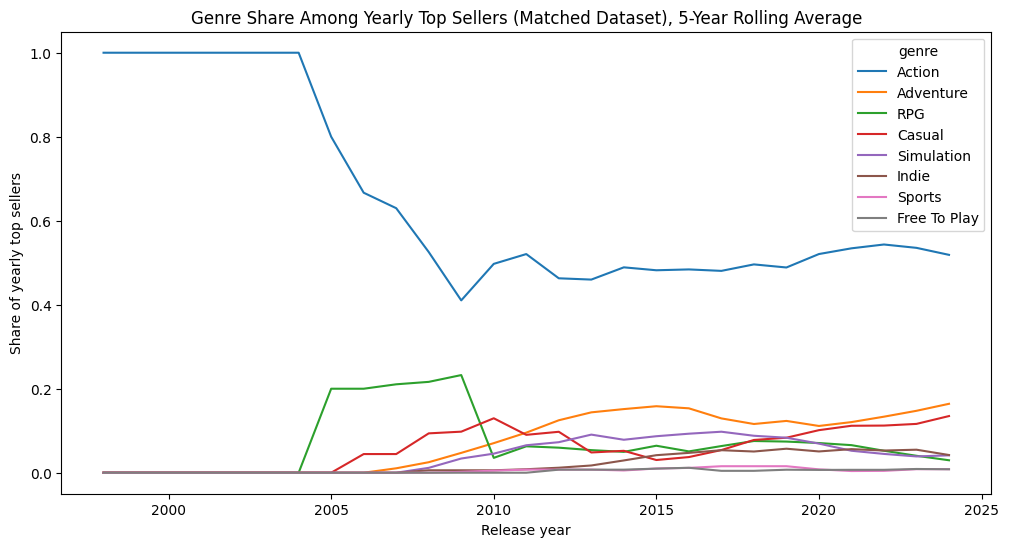

In [38]:
m_yearly_top = (
    mdf.dropna(subset=["release_year"])
    .assign(release_year=lambda d: d["release_year"].astype(int))
    .sort_values(["release_year", "vg_global_sales"], ascending=[True, False])
    .groupby("release_year", group_keys=False)
    .head(100)
)
m_ycounts = (
    m_yearly_top.groupby(["release_year", "genre"])["name"]
    .count().rename("games").reset_index()
)
m_ytotals = m_yearly_top.groupby("release_year")["name"].count().rename("year_top_games")
m_ycounts = m_ycounts.merge(m_ytotals, on="release_year")
m_ycounts["genre_share"] = m_ycounts["games"] / m_ycounts["year_top_games"]
m_trend_pivot = m_ycounts.pivot_table(index="release_year", columns="genre", values="genre_share", fill_value=0)
m_rolling_trend = m_trend_pivot.rolling(5, min_periods=1).mean()
m_top_genres = m_top100_dist.head(8).index.tolist()
ax = m_rolling_trend[m_top_genres].plot(figsize=(12, 6))
ax.set_title("Genre Share Among Yearly Top Sellers (Matched Dataset), 5-Year Rolling Average")
ax.set_ylabel("Share of yearly top sellers")
ax.set_xlabel("Release year")
plt.show()